In [7]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy

t_serial = float(pd.read_csv("../Etapa 0/resultados.csv")["tempo"].mean())
results = {"N processos": [], "Méd tempo total": [], "DPP": [], "Speedup": []}

In [ ]:
t_serial = float(pd.read_csv("../Etapa 0/resultados.csv")["tempo"].mean())

res01 = pd.read_csv("../Etapa 1/resultadosT1.csv")
res02 = pd.read_csv("../Etapa 1/resultadosT2.csv")
res04 = pd.read_csv("../Etapa 1/resultadosT4.csv")
res08 = pd.read_csv("../Etapa 1/resultadosT8.csv")

# Remove o pior caso
res01 = res01.drop(res01["tempo"].idxmax())
res02 = res02.drop(res02["tempo"].idxmax())
res04 = res04.drop(res04["tempo"].idxmax())
res08 = res08.drop(res08["tempo"].idxmax())

resumo = {"N threads":[], "Méd tempo (ms)":[], "DPP":[], "Speedup méd":[], "Eficiência":[], "iters":[], "sse":[]}
for table, nthreads in zip([res01, res02, res04, res08], [1, 2, 4, 8]):
    resumo["N threads"].append(nthreads)
    resumo["Méd tempo (ms)"].append(table["tempo"].mean())
    resumo["DPP"].append(table["tempo"].std())
    resumo["Speedup méd"].append(t_serial/table["tempo"].mean())
    resumo["Eficiência"].append(t_serial/table["tempo"].mean()/nthreads)
    resumo["iters"].append(table["iters"].mean())
    resumo["sse"].append(table["sse"].mean())
df_resumo = pd.DataFrame(resumo)
df_resumo

,N threads,Méd tempo (ms),DPP,Speedup méd,Eficiência,iters,sse
0,1,1672.705263,15.450008,0.977470,0.977470,13.0,23.491154
1,2,874.794737,34.170983,1.869033,0.934516,13.0,23.491154
2,4,534.963158,17.358322,3.056323,0.764081,13.0,23.491154
3,8,319.521053,8.609399,5.117096,0.639637,13.0,23.491154


In [8]:
np1 = pd.read_csv("resultadosNP1.csv")
np2 = pd.read_csv("resultadosNP2.csv")
np3 = pd.read_csv("resultadosNP3.csv")
np4 = pd.read_csv("resultadosNP4.csv")

# Remoção dos piores casos
np1 = np1.drop(np1["tempo_total_ms"].idxmax())
np2 = np2.drop(np2["tempo_total_ms"].idxmax())
np3 = np3.drop(np3["tempo_total_ms"].idxmax())
np4 = np4.drop(np4["tempo_total_ms"].idxmax())

for table, np in zip([np1, np2, np3, np4], [1, 2, 3, 4]):
    results["N processos"].append(np)
    results["Méd tempo total"].append(table["tempo_total_ms"].mean())
    results["DPP"].append(table["tempo_total_ms"].std())
    results["Speedup"].append(t_serial/table["tempo_total_ms"].mean())

df_results = pd.DataFrame(results)
df_results


,N processos,Méd tempo total,DPP,Speedup
0,1,1598.468421,34.245909,1.022867
1,2,886.131579,27.335590,1.845121
2,3,704.957895,17.725948,2.319316
3,4,593.700000,12.939474,2.753950


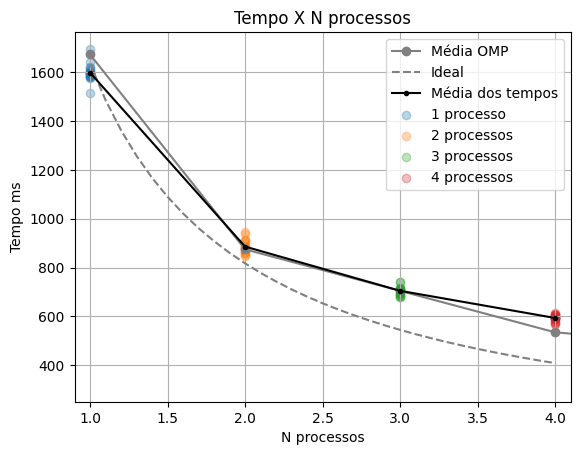

In [56]:
plt.plot(df_resumo["N threads"], df_resumo["Méd tempo (ms)"], label="Média OMP", marker="o", color="grey")
plt.plot(numpy.arange(1, 4.1, 0.1),[t_serial/x for x in numpy.arange(1, 4.1, 0.1)], "--", color="grey", label="Ideal")
plt.plot(df_results["N processos"], df_results["Méd tempo total"], color="black", label="Média dos tempos", marker=".")
plt.scatter([1]*len(np1.tempo_total_ms), np1.tempo_total_ms, alpha=0.3, label="1 processo")
plt.scatter([2]*len(np2.tempo_total_ms), np2.tempo_total_ms, alpha=0.3, label="2 processos")
plt.scatter([3]*len(np3.tempo_total_ms), np3.tempo_total_ms, alpha=0.3, label="3 processos")
plt.scatter([4]*len(np4.tempo_total_ms), np4.tempo_total_ms, alpha=0.3, label="4 processos")
plt.grid(True)
plt.xlabel("N processos")
plt.ylabel("Tempo ms")
plt.title("Tempo X N processos")
plt.xlim(left=0.9, right=4.1)
plt.legend()
plt.show()

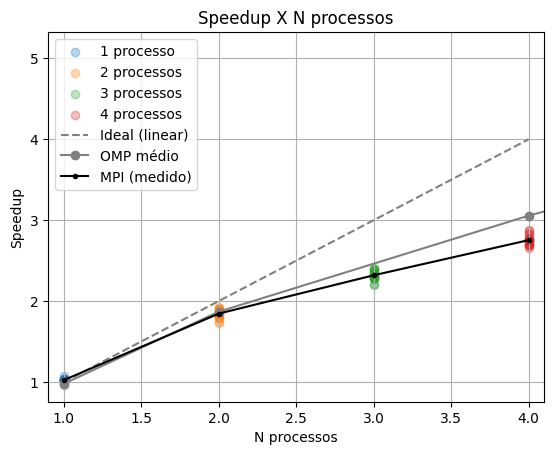

In [53]:
plt.scatter([1]*len(np1.tempo_total_ms), t_serial/np1.tempo_total_ms, alpha=0.3, label="1 processo")
plt.scatter([2]*len(np2.tempo_total_ms), t_serial/np2.tempo_total_ms, alpha=0.3, label="2 processos") 
plt.scatter([3]*len(np3.tempo_total_ms), t_serial/np3.tempo_total_ms, alpha=0.3, label="3 processos")
plt.scatter([4]*len(np4.tempo_total_ms), t_serial/np4.tempo_total_ms, alpha=0.3, label="4 processos")
plt.plot([1, 4], [1, 4], '--', color="gray", label="Ideal (linear)")
plt.plot(df_resumo["N threads"], df_resumo["Speedup méd"], color="grey", label="OMP médio", marker="o")
plt.plot(df_results["N processos"], df_results["Speedup"], color="black", label="MPI (medido)", marker=".")
plt.grid(True)
plt.xlabel("N processos")
plt.ylabel("Speedup")
plt.title("Speedup X N processos")
plt.xlim(left=0.9, right=4.1)
plt.legend()
plt.show()

# All reduce

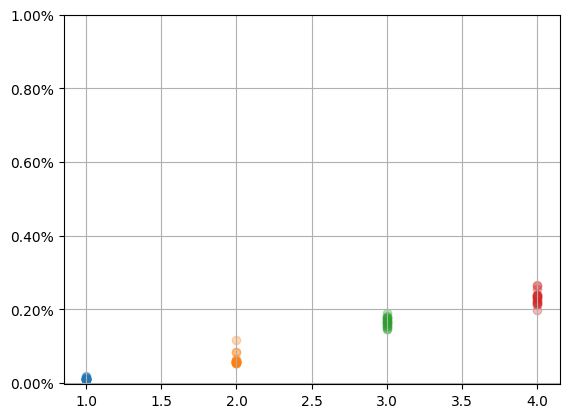

In [ ]:
import matplotlib.ticker as mtick

for df in [np1, np2, np3, np4]:
    df["reduce percentage"] = df.allreduce_ms / df.tempo_total_ms

ax = plt.gca()
ax.yaxis.set_major_formatter(mtick.PercentFormatter(xmax=1))

plt.scatter([1]*len(np1), np1["reduce percentage"], alpha=0.3)
plt.scatter([2]*len(np2), np2["reduce percentage"], alpha=0.3)
plt.scatter([3]*len(np3), np3["reduce percentage"], alpha=0.3)
plt.scatter([4]*len(np4), np4["reduce percentage"], alpha=0.3)
plt.ylim(top=0.01)
plt.grid(True)
plt.show()


O tempo de all reduce cresce com o número de processos, porém continua irrelevante (<0,3%)